<a href="https://colab.research.google.com/github/Vincent-L0/A01-data-wrangling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Vincent Lam

**Date:** 9/2/26

In [31]:
# Your Phase 1 solution to the problem goes here.

import pandas as pd

# create dataframe using airbnb csv file
df_airbnb = pd.read_csv('/content/airbnb_hw.csv')

# create a new dataframe to hold cleaned data
df_airbnbclean = df_airbnb.copy()

# convert price variables from numeric to string to remove comma. This was chosen as it allows the prices to be accessed as numbers and for ease of calculation
df_airbnbclean['Price'] = df_airbnb['Price'].astype(str).str.replace(',','')

# convert price variables from string back to numeric
df_airbnbclean['Price'] = pd.to_numeric(df_airbnbclean['Price'])

print(df_airbnbclean['Price'].isna().sum())

# interpretation: there are no missing values because all prices with a comma were converted into their non-comma form without any losses.

# create dataframe using force csv file
df_police = pd.read_csv('/content/mn_police_use_of_force.csv')

# create a new dataframe to hold cleaned data
df_policeclean = df_police.copy()

# replace missing values with "Unknown" to understand pattern for missing values
df_policeclean['subject_injury'] = df_police['subject_injury'].fillna("Unknown")

# calculate proportion of missing values
print((df_policeclean['subject_injury'] == "Unknown").sum()/len(df_policeclean))

# 0.76 is the proportion of missing values, this is a concern because it demonstrates a gap in police records and non-transparency.

print(pd.crosstab(df_policeclean['subject_injury'], df_policeclean['force_type']))

# interpretation: missing injury records tend to proportionally appear more often than recorded injuries for each of the force types.

0
0.7619342359767892


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Unknown,2,7051,1421,0,27,74,87,0,170,31,985
Yes,2,1286,41,0,44,40,0,2,0,44,172


5.0
2026.0
0.8342935528120713
0.8878143133462283
18
7099


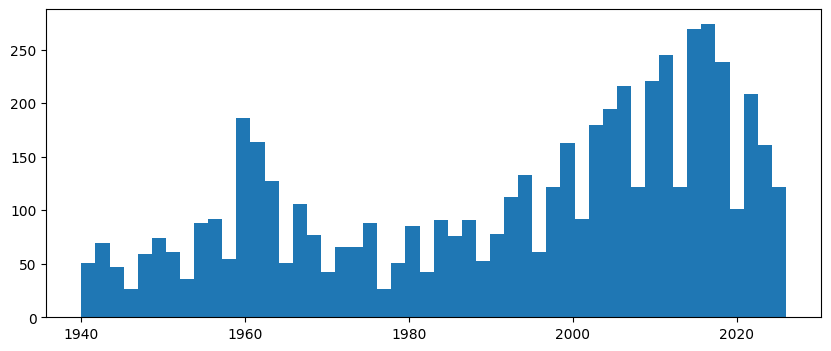

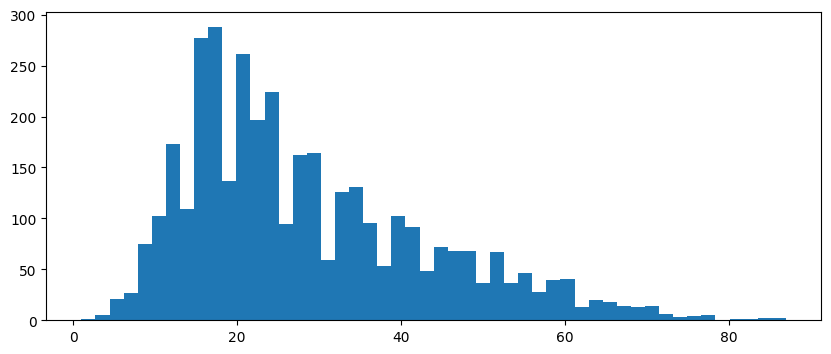

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# create dataframe using sharks csv file
df_sharks = pd.read_excel('/content/GSAF5.xls')

df_sharks['Year'] = pd.to_numeric(df_sharks['Year'])

# drop rows with incorrect year values (0000)
df_sharksclean = df_sharks[df_sharks['Year'] != 0000].copy()

# drop rows with missing values
df_sharksclean = df_sharksclean.dropna(subset = ['Year'])

# get range of years
minYear = df_sharksclean['Year'].min()
maxYear = df_sharksclean['Year'].max()

print(minYear)
print(maxYear)

# Year ranges from 5 to 2026

# drop rows with years before 1940
df_sharks_past1940 = df_sharksclean[df_sharksclean['Year'] >= 1940].copy()

# create histogram based on the number of shark attacks each year
plt.figure(figsize=(10,4))
minYear_1940 = int(df_sharks_past1940['Year'].min())
maxYear_1940 = int(df_sharks_past1940['Year'].max())
plt.hist(df_sharks_past1940['Year'],
         bins = 50)
# shark attacks are increasing in frequency over time

# clean age column, drop rows with ? for age and remove 's, +, and non-numeric ages
df_sharks_past1940 = df_sharks_past1940[df_sharks_past1940['Age'] != '?']
df_sharks_past1940['Age'] = df_sharks_past1940['Age'].replace("'s",'')
df_sharks_past1940['Age'] = df_sharks_past1940['Age'].replace("+",'')

# convert to numeric
df_sharks_past1940['Age'] = pd.to_numeric(df_sharks_past1940['Age'], errors = 'coerce').dropna()

# create histogram based on the age of victims
plt.figure(figsize=(10,4))
minAge_1940 = int(df_sharks_past1940['Age'].min())
maxAge_1940 = int(df_sharks_past1940['Age'].max())
plt.hist(df_sharks_past1940['Age'],
         bins = 50)

# remove observations with missing gender
df_sharks_past1940_genderclean = df_sharks_past1940.copy()
df_sharks_past1940_genderclean = df_sharks_past1940.dropna(subset = ['Age'])

# calculate proportion of male victims
print((df_sharks_past1940_genderclean['Sex'] == "M").sum()/len(df_sharks_past1940_genderclean))

# 0.83 is the proportion of male victims

# define allowed types
allowed_types = ['Provoked', 'Unprovoked', 'Unknown']

# remove non-allowed types
df_sharks_past1940_typefilter = df_sharks_past1940[df_sharks_past1940['Type'].isin(allowed_types)].copy()

# calculate proportion of unprovoked victims
print((df_sharks_past1940_typefilter['Type'] == "Unprovoked").sum()/len(df_sharks_past1940_typefilter))

# 0.89 is the proportion of unprovoked victims
df = pd.read_excel('/content/GSAF5.xls')
print(df['Type'].isna().sum())
print(df['Type'].count())


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...



### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [4]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]